# Molecular Dynamics of bulk water with NequIP and CP2K

## [Colab link](https://colab.research.google.com/github/gabriele16/cp2k/blob/colab-nequip-2024.2/colab/nequip-cp2k-water-tutorial-precompiled.ipynb)

<img src="https://github.com/gabriele16/cp2k/blob/master/tools/logo/cp2k_logo_500.png?raw=true" width="35%"> <img src="https://github.com/mir-group/nequip_mrs_tutorial/blob/master/nequip3.png?raw=true" width="40%">




### Tutorial by Gabriele Tocci

### The water trajectory is obtained with the SCAN functional at 300 K and is the last 5 ps (10k frames) of a trajectory used in the paper by Herrero et al.: [Connection between water's dynamical and structural properties: Insights from ab initio simulations ](https://www.pnas.org/doi/10.1073/pnas.2121641119)

### Open in colab and change the runtime to use the GPU (T4 recommended)

### CP2K supports the following GPU architectures:
* K20X, K40, K80, P100, V100, Mi50, Mi100, Mi250, T4


### Change to cuda 11.8

In [ ]:

# Set noninteractive mode for apt
! export DEBIAN_FRONTEND=noninteractive

# Download the repository pin file
! wget https://developer.download.nvidia.com/compute/cuda/repos/ubuntu1804/x86_64/cuda-ubuntu1804.pin
! sudo mv cuda-ubuntu1804.pin /etc/apt/preferences.d/cuda-repository-pin-600

# Add NVIDIA’s GPG key (the warning about apt-key is okay)
! sudo apt-key adv --fetch-keys https://developer.download.nvidia.com/compute/cuda/repos/ubuntu1804/x86_64/7fa2af80.pub

# Add the CUDA repository non-interactively (the -y flag skips the prompt)
! sudo add-apt-repository -y "deb https://developer.download.nvidia.com/compute/cuda/repos/ubuntu1804/x86_64/ /"

# Update package lists
! DEBIAN_FRONTEND=noninteractive sudo apt-get update

# Install CUDA 11.8
! echo 'keyboard-configuration keyboard-configuration/layoutcode string us' | sudo debconf-set-selections
! echo 'keyboard-configuration keyboard-configuration/modelcode string pc105' | sudo debconf-set-selections
! echo 'keyboard-configuration keyboard-configuration/variantcode string ' | sudo debconf-set-selections
! sudo DEBIAN_FRONTEND=noninteractive apt-get install -y cuda-11-8


# Update environment variables for this session
! export PATH=/usr/local/cuda-11.8/bin:$PATH
! export LD_LIBRARY_PATH=/usr/local/cuda-11.8/lib64:$LD_LIBRARY_PATH



! sudo rm -rf /usr/local/cuda
! sudo rm -rf /usr/local/cuda-12.5/
! sudo rm -rf /usr/local/cuda-12
! sudo ln -s /usr/local/cuda-11.8 /usr/local/cuda
! export PATH=/usr/local/cuda/bin:$PATH
! export LD_LIBRARY_PATH=/usr/local/cuda/lib64:$LD_LIBRARY_PATH
! nvcc --version


### Clone cp2k v2024.2 with some tools and data for this tutorial

In [ ]:
! cd /content && git clone --recursive -b colab-nequip-2024.2  https://github.com/gabriele16/cp2k.git cp2k

### Run the script below to download and install some packages.

- Select  `--install-cp2k=yes` to install the cp2k toolchain and compile cp2k from scratch (slower and not recommended).
- Select  `--install-cp2k=no` to download a pre-compiled cp2k executable and compiled libraries

In [ ]:
! cd /content/cp2k/colab && chmod 755 install_torch_cp2k_colab.sh && ./install_torch_cp2k_colab.sh --install-cp2k=no

In [4]:
%%bash

# Check CUDA and NVCC
echo "Checking CUDA version and NVCC..."
nvcc --version
nvidia-smi
which nvcc

Checking CUDA version and NVCC...
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2022 NVIDIA Corporation
Built on Wed_Sep_21_10:33:58_PDT_2022
Cuda compilation tools, release 11.8, V11.8.89
Build cuda_11.8.r11.8/compiler.31833905_0
Wed Dec 17 11:44:30 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |              

# Restart python session now and restart from the cell below
* In case there is an error check that numpy version is ~1.26. If it is not, restart the python session


In [ ]:

import pandas as pd
import torch
#import nglview as nv
import numpy as np
from google.colab import output
output.enable_custom_widget_manager()

# if np.__version__[:4] != "1.26":
#     raise RuntimeError(f"Incorrect NumPy version: {np.__version__}. Expected 1.26.x")


import site

site.main()
# set to allow anonymous WandB
import os

os.environ["WANDB_ANONYMOUS"] = "must"

import warnings
import os
data_dir = "/content/cp2k/colab/AIMD_data/"

np.random.seed(0)
if torch.cuda.is_available():
  torch.cuda.manual_seed(0)
else:
  torch.manual_seed(0)

## 3 Steps:
* Train: using a data set, train the neural network
* Deploy: convert the Python-based model into a stand-alone potential file for fast execution
* Run: run Molecular Dynamics in CP2K

### Train a model

Here, we will train a NequIP potential on the following system

* Water
* sampled at T=300K from AIMD
* Using 100 training configurations and 50 validation configurations
* The units of the reference data are in eV and A.

#### Extract the AIMD trajectory

In [ ]:
! cd cp2k/colab/ && tar -xzvf AIMD_data.tar.gz

### Below we explicitly write the input to train the model with NequIP/Allegro

In [7]:

nequip_input = """

# IMPORTANT: READ THIS

# This is a full yaml file with all nequip options.
# It is primarily intented to serve as documentation/reference for all options
# For a simpler yaml file containing all necessary features to get you started, we strongly recommend to start with configs/example.yaml

# Two folders will be used during the training: 'root'/process and 'root'/'run_name'
# run_name contains logfiles and saved models
# process contains processed data sets
# if 'root'/'run_name' exists, 'root'/'run_name'_'year'-'month'-'day'-'hour'-'min'-'s' will be used instead.
root: results/water
run_name: example-run-water
seed: 123 # model seed
dataset_seed: 456 # data set seed
append: true # set true if a restarted run should append to the previous log file
default_dtype: float32 # type of float to use, e.g. float32 and float64
allow_tf32: false # whether to use TensorFloat32 if it is available
# device:  cuda                                                                   # which device to use. Default: automatically detected cuda or "cpu"

# network
r_max: 4.9 # cutoff radius in length units, here Angstrom, this is an important hyperparamter to scan
num_layers: 3 # number of interaction blocks, we find 3-5 to work best

l_max: 1 # the maximum irrep order (rotation order) for the network's features, l=1 is a good default, l=2 is more accurate but slower
parity: true # whether to include features with odd mirror parityy; often turning parity off gives equally good results but faster networks, so do consider this
num_features: 32 # the multiplicity of the features, 32 is a good default for accurate network, if you want to be more accurate, go larger, if you want to be faster, go lower

# alternatively, the irreps of the features in various parts of the network can be specified directly:
# the following options use e3nn irreps notation
# either these four options, or the above three options, should be provided--- they cannot be mixed.
# chemical_embedding_irreps_out: 32x0e                                              # irreps for the chemical embedding of species
# feature_irreps_hidden: 32x0o + 32x0e + 32x1o + 32x1e                              # irreps used for hidden features, here we go up to lmax=1, with even and odd parities; for more accurate but slower networks, use l=2 or higher, smaller number of features is faster
# irreps_edge_sh: 0e + 1o                                                           # irreps of the spherical harmonics used for edges. If a single integer, indicates the full SH up to L_max=that_integer
# conv_to_output_hidden_irreps_out: 16x0e                                           # irreps used in hidden layer of output block

nonlinearity_type: gate # may be 'gate' or 'norm', 'gate' is recommended
resnet:
  false # set true to make interaction block a resnet-style update
  # the resnet update will only be applied when the input and output irreps of the layer are the same

# scalar nonlinearities to use — available options are silu, ssp (shifted softplus), tanh, and abs.
# Different nonlinearities are specified for e (even) and o (odd) parity;
# note that only tanh and abs are correct for o (odd parity).
# silu typically works best for even
nonlinearity_scalars:
  e: silu
  o: tanh

nonlinearity_gates:
  e: silu
  o: tanh

# radial network basis
num_basis: 8 # number of basis functions used in the radial basis, 8 usually works best
BesselBasis_trainable: true # set true to train the bessel weights
PolynomialCutoff_p: 6 # p-exponent used in polynomial cutoff function, smaller p corresponds to stronger decay with distance

# radial network
invariant_layers: 2 # number of radial layers, usually 1-3 works best, smaller is faster
invariant_neurons: 64 # number of hidden neurons in radial function, smaller is faster
avg_num_neighbors: auto # number of neighbors to divide by, null => no normalization, auto computes it based on dataset
use_sc: true # use self-connection or not, usually gives big improvement

# to specify different parameters for each convolutional layer, try examples below
# layer1_use_sc: true                                                             # use "layer{i}_" prefix to specify parameters for only one of the layer,
# priority for different definitions:
#   invariant_neurons < InteractionBlock_invariant_neurons < layer{i}_invariant_neurons

# data set
# there are two options to specify a dataset, npz or ase
# npz works with npz files, ase can ready any format that ase.io.read can read
# in most cases working with the ase option and an extxyz file is by far the simplest way to do it and we strongly recommend using this
# simply provide a single extxyz file that contains the structures together with energies and forces (generated with ase.io.write(atoms, format='extxyz', append=True))

include_keys:
  - user_label
key_mapping:
  user_label: label0

# alternatively, you can read directly from a VASP OUTCAR file (this will only read that single OUTCAR)
# # for VASP OUTCAR, the yaml input should be
# dataset: ase
# dataset_file_name: OUTCAR
# ase_args:
#   format: vasp-out
# important VASP note: the ase vasp parser stores the potential energy to "free_energy" instead of "energy".
# Here, the key_mapping maps the external name (key) to the NequIP default name (value)
# key_mapping:
#   free_energy: total_energy

# npz example
# the keys used need to be stated at least once in key_mapping, npz_fixed_field_keys or include_keys
# key_mapping is used to map the key in the npz file to the NequIP default values (see data/_key.py)
# all arrays are expected to have the shape of (nframe, natom, ?) except the fixed fields
# note that if your data set uses pbc, you need to also pass an array that maps to the nequip "pbc" key
# dataset: npz                                                                       # type of data set, can be npz or ase
# dataset_url: http://quantum-machine.org/gdml/data/npz/toluene_ccsd_t.zip           # url to download the npz. optional
# dataset_file_name: ./benchmark_data/toluene_ccsd_t-train.npz                       # path to data set file
# key_mapping:
#   z: atomic_numbers                                                                # atomic species, integers
#   E: total_energy                                                                  # total potential eneriges to train to
#   F: forces                                                                        # atomic forces to train to
#   R: pos                                                                           # raw atomic positions
# npz_fixed_field_keys:                                                              # fields that are repeated across different examples
#   - atomic_numbers

# A list of chemical species found in the data. The NequIP atom types will be named after the chemical symbols and ordered by atomic number in ascending order.
# (In this case, NequIP's internal atom type 0 will be named H and type 1 will be named C.)
# Atoms in the input will be assigned NequIP atom types according to their atomic numbers.
chemical_symbols:
  - H
  - O

# Alternatively, you may explicitly specify which chemical species in the input will map to NequIP atom type 0, which to atom type 1, and so on.
# Other than providing an explicit order for the NequIP atom types, this option behaves the same as `chemical_symbols`
# chemical_symbol_to_type:
#   H: 0
#   C: 1

# Alternatively, if the dataset has type indices, you may give the names for the types in order:
# (this also sets the number of types)
# type_names:
#   - my_type
#   - atom
#   - thing

# As an alternative option to npz, you can also pass data ase ASE Atoms-objects
# This can often be easier to work with, simply make sure the ASE Atoms object
# has a calculator for which atoms.get_potential_energy() and atoms.get_forces() are defined
dataset: ase
dataset_file_name: ./cp2k/colab/AIMD_data/conc_wat_pos_frc.extxyz # need to be a format accepted by ase.io.read
ase_args: # any arguments needed by ase.io.read
  format: extxyz

# If you want to use a different dataset for validation, you can specify
# the same types of options using a `validation_` prefix:
# validation_dataset: ase
# validation_dataset_file_name: xxx.xyz                                            # need to be a format accepted by ase.io.read

# logging
#wandb: true # we recommend using wandb for logging
#wandb_project: water-example # project name used in wandb
#wandb_watch: false

# see https://docs.wandb.ai/ref/python/watch
# wandb_watch_kwargs:
#   log: all
#   log_freq: 1
#   log_graph: true

verbose: info # the same as python logging, e.g. warning, info, debug, error. case insensitive
log_batch_freq: 1 # batch frequency, how often to print training errors withinin the same epoch
log_epoch_freq: 1 # epoch frequency, how often to print
save_checkpoint_freq: -1 # frequency to save the intermediate checkpoint. no saving of intermediate checkpoints when the value is not positive.
save_ema_checkpoint_freq: -1 # frequency to save the intermediate ema checkpoint. no saving of intermediate checkpoints when the value is not positive.

# training
n_train: 100 # number of training data
n_val: 50 # number of validation data
learning_rate: 0.005 # learning rate, we found values between 0.01 and 0.005 to work best - this is often one of the most important hyperparameters to tune
batch_size: 5 # batch size, we found it important to keep this small for most applications including forces (1-5); for energy-only training, higher batch sizes work better
validation_batch_size: 10 # batch size for evaluating the model during validation. This does not affect the training results, but using the highest value possible (<=n_val) without running out of memory will speed up your training.
max_epochs: 100000 # stop training after _ number of epochs, we set a very large number here, it won't take this long in practice and we will use early stopping instead
train_val_split: random # can be random or sequential. if sequential, first n_train elements are training, next n_val are val, else random, usually random is the right choice
shuffle: true # If true, the data loader will shuffle the data, usually a good idea
metrics_key: validation_loss # metrics used for scheduling and saving best model. Options: `set`_`quantity`, set can be either "train" or "validation, "quantity" can be loss or anything that appears in the validation batch step header, such as f_mae, f_rmse, e_mae, e_rmse
use_ema: true # if true, use exponential moving average on weights for val/test, usually helps a lot with training, in particular for energy errors
ema_decay: 0.99 # ema weight, typically set to 0.99 or 0.999
ema_use_num_updates: true # whether to use number of updates when computing averages
report_init_validation: true # if True, report the validation error for just initialized model

# early stopping based on metrics values.
# LR, wall and any keys printed in the log file can be used.
# The key can start with Training or validation. If not defined, the validation value will be used.
early_stopping_patiences: # stop early if a metric value stopped decreasing for n epochs
  validation_loss: 50

early_stopping_delta: # If delta is defined, a decrease smaller than delta will not be considered as a decrease
  validation_loss: 0.005

early_stopping_cumulative_delta: false # If True, the minimum value recorded will not be updated when the decrease is smaller than delta

early_stopping_lower_bounds: # stop early if a metric value is lower than the bound
  LR: 1.0e-5

early_stopping_upper_bounds: # stop early if a metric value is higher than the bound
  cumulative_wall: 1.0e+100

# loss function
loss_coeffs: # different weights to use in a weighted loss functions
  forces: 1 # if using PerAtomMSELoss, a default weight of 1:1 on each should work well
  total_energy:
    - 1
    - PerAtomMSELoss

# # default loss function is MSELoss, the name has to be exactly the same as those in torch.nn.
# the only supprted targets are forces and total_energy

# here are some example of more ways to declare different types of loss functions, depending on your application:
# loss_coeffs:
#   total_energy: MSELoss
#
# loss_coeffs:
#   total_energy:
#   - 3.0
#   - MSELoss
#
# loss_coeffs:
#   total_energy:
#   - 1.0
#   - PerAtomMSELoss
#
# loss_coeffs:
#   forces:
#   - 1.0
#   - PerSpeciesL1Loss
#
# loss_coeffs: total_energy
#
# loss_coeffs:
#   total_energy:
#   - 3.0
#   - L1Loss
#   forces: 1.0

# output metrics
metrics_components:
  - - forces # key
    - mae # "rmse" or "mae"
  - - forces
    - rmse
  - - forces
    - mae
    - PerSpecies: True # if true, per species contribution is counted separately
      report_per_component: False # if true, statistics on each component (i.e. fx, fy, fz) will be counted separately
  - - forces
    - rmse
    - PerSpecies: True
      report_per_component: False
  - - total_energy
    - mae
  - - total_energy
    - mae
    - PerAtom: True # if true, energy is normalized by the number of atoms

# optimizer, may be any optimizer defined in torch.optim
# the name `optimizer_name`is case sensitive
optimizer_name: Adam # default optimizer is Adam
optimizer_amsgrad: false
optimizer_betas: !!python/tuple
  - 0.9
  - 0.999
optimizer_eps: 1.0e-08
optimizer_weight_decay: 0

# gradient clipping using torch.nn.utils.clip_grad_norm_
# see https://pytorch.org/docs/stable/generated/torch.nn.utils.clip_grad_norm_.html#torch.nn.utils.clip_grad_norm_
# setting to inf or null disables it
max_gradient_norm: null

# lr scheduler, currently only supports the two options listed below, if you need more please file an issue
# first: on-plateau, reduce lr by factory of lr_scheduler_factor if metrics_key hasn't improved for lr_scheduler_patience epoch
lr_scheduler_name: ReduceLROnPlateau
lr_scheduler_patience: 100
lr_scheduler_factor: 0.5

# second, cosine annealing with warm restart
# lr_scheduler_name: CosineAnnealingWarmRestarts
# lr_scheduler_T_0: 10000
# lr_scheduler_T_mult: 2
# lr_scheduler_eta_min: 0
# lr_scheduler_last_epoch: -1

# we provide a series of options to shift and scale the data
# these are for advanced use and usually the defaults work very well
# the default is to scale the energies and forces by scaling them by the force standard deviation and to shift the energy by its mean
# in certain cases, it can be useful to have a trainable shift/scale and to also have species-dependent shifts/scales for each atom

per_species_rescale_scales_trainable: false
# whether the scales are trainable. Defaults to False. Optional
per_species_rescale_shifts_trainable: false
# whether the shifts are trainable. Defaults to False. Optional
per_species_rescale_shifts: dataset_per_atom_total_energy_mean
# initial atomic energy shift for each species. default to the mean of per atom energy. Optional
# the value can be a constant float value, an array for each species, or a string
# string option include:
# *  "dataset_per_atom_total_energy_mean", which computes the per atom average
# *  "dataset_per_species_total_energy_mean", which automatically compute the per atom energy mean using a GP model
per_species_rescale_scales: dataset_forces_rms
# initial atomic energy scale for each species. Optional.
# the value can be a constant float value, an array for each species, or a string
# string option include:
# *  "dataset_per_atom_total_energy_std", which computes the per atom energy std
# *  "dataset_per_species_total_energy_std", which uses the GP model uncertainty
# *  "dataset_per_species_forces_rms", which compute the force rms for each species
# If not provided, defaults to dataset_per_species_force_rms or dataset_per_atom_total_energy_std, depending on whether forces are being trained.
# per_species_rescale_kwargs:
#   total_energy:
#     alpha: 0.1
#     max_iteration: 20
#     stride: 100
# keywords for GP decomposition of per specie energy. Optional. Defaults to 0.1
# per_species_rescale_arguments_in_dataset_units: True
# if explicit numbers are given for the shifts/scales, this parameter must specify whether the given numbers are unitless shifts/scales or are in the units of the dataset. If ``True``, any global rescalings will correctly be applied to the per-species values.

# global energy shift and scale
# When "dataset_total_energy_mean", the mean energy of the dataset. When None, disables the global shift. When a number, used directly.
# Warning: if this value is not None, the model is no longer size extensive
#global_rescale_shift: null

# global energy scale. When "dataset_force_rms", the RMS of force components in the dataset. When "dataset_total_energy_std", the stdev of energies in the dataset. When null, disables the global scale. When a number, used directly.
# If not provided, defaults to either dataset_force_rms or dataset_total_energy_std, depending on whether forces are being trained.
#global_rescale_scale: dataset_forces_rms

# whether the shift of the final global energy rescaling should be trainable
#global_rescale_shift_trainable: false

# whether the scale of the final global energy rescaling should be trainable
# global_rescale_scale_trainable: false
# # full block needed for per specie rescale
# global_rescale_shift: null
# global_rescale_shift_trainable: false
# global_rescale_scale: dataset_forces_rms
# global_rescale_scale_trainable: false
# per_species_rescale_trainable: true
# per_species_rescale_shifts: dataset_per_atom_total_energy_mean
# per_species_rescale_scales: dataset_per_atom_total_energy_std

# # full block needed for global rescale
# global_rescale_shift: dataset_total_energy_mean
# global_rescale_shift_trainable: false
# global_rescale_scale: dataset_forces_rms
# global_rescale_scale_trainable: false
# per_species_rescale_trainable: false
# per_species_rescale_shifts: null
# per_species_rescale_scales: null

# Options for e3nn's set_optimization_defaults. A dict:
# e3nn_optimization_defaults:
#   explicit_backward: True

global_rescale_shift: null
global_rescale_shift_trainable: false
global_rescale_scale: dataset_forces_rms
global_rescale_scale_trainable: false
per_species_rescale_shifts_trainable: false
per_species_rescale_scales_trainable: true
per_species_rescale_shifts: dataset_per_species_total_energy_mean
per_species_rescale_scales: dataset_per_species_forces_rms

"""

!mkdir nequip_train
with open("nequip_train/water-example.yaml", "w") as f:
    f.write(nequip_input)

mkdir: cannot create directory ‘nequip_train’: File exists


In [ ]:
!rm -rf ./results
!nequip-train nequip_train/water-example.yaml

### Deploy the model

We now convert the model to a potential file. This makes it independent of NequIP and we can load it in CP2K to run MD.

In [ ]:
!nequip-deploy build --train-dir /content/results/water/example-run-water water-deploy.pth

## Evaluate Test Error

Before running inference, we run the nequip-evaluate command to compute the test error on unseen data.

In [ ]:
!nequip-evaluate --train-dir results/water/example-run-water --batch-size 50 --output /content/results/water/example-run-water/water_evaluated.xyz

We get rather small errors in the forces of ~50 meV/A

# CP2K

We are now in a position to run MD with our potential.

Set up a simple cp2k input file, you can find an example file inside ```cp2k/tests/Fist/regtest-nequip```

CAUTION: Be careful with the units of the .pth model file. It's better to explicitly specify the units of this file since CP2K input defaults as Angstrom for lengths and A.U. for everything else.

### We now run MD in the NVT ensemble for 10 ps (20,000 steps)

---



In [11]:
cp2k_input_md = """
&GLOBAL
  PROJECT water
  RUN_TYPE MD
&END GLOBAL
&FORCE_EVAL
  METHOD FIST
  &MM
    &FORCEFIELD
     &NONBONDED
     &NEQUIP
        ATOMS H O
        PARM_FILE_NAME ./water-deploy.pth
        UNIT_COORDS angstrom
        UNIT_ENERGY eV
        UNIT_FORCES eV*angstrom^-1
     &END NEQUIP
    &END NONBONDED
    &END FORCEFIELD
    &POISSON
      &EWALD
        EWALD_TYPE none
      &END EWALD
    &END POISSON
  &END MM
  &SUBSYS
    &CELL
      ABC 9.85 9.85 9.85
#      MULTIPLE_UNIT_CELL 4 4 4
    &END CELL
    &COORD
H     42.886169670000001   -0.055681660000000001      38.329161120000002
H     34.202588720000001              -0.6185484      37.365568080000003
H     30.080392589999999     -2.0124176500000002      36.480796079999998
H     28.705791179999999     -2.6880392799999999      36.602098329999997
H            36.24794267    -0.51634849000000005      34.492359610000001
H     37.696472460000003   -0.041087279999999997      35.014073510000003
H     27.760669979999999      7.4854206000000003      33.927691950000003
H     28.816099959999999              6.49857774             34.21636084
H     37.157637200000003      9.0188280800000005      31.926581209999998
H     38.606381650000003      9.5820079600000003      32.343597279999997
H     34.303195930000001      2.2195014400000002      45.988045190000001
H     33.244413940000001              1.30253325      46.469842720000003
H     38.728617479999997     -5.0541897699999998      26.074396839999999
H     38.348392150000002     -6.2832846900000003      26.986725310000001
H     32.864252090000001              3.20606327               30.897116
H     31.290408809999999      3.0871834699999998             30.62739775
H     33.751986969999997             -3.13832624      39.672760769999996
H     34.664297990000001             -3.66438591      38.646602719999997
H     42.717321439999999      5.1246883700000003      32.588340119999998
H            41.56274552      5.5893544000000004      33.417490280000003
H     32.428380089999997      9.1182520999999994             30.54776786
H             32.6432407             10.77068308             30.48427787
H     31.484867080000001      4.6777144699999997      37.395719499999998
H     32.317188299999998     -6.2287496200000003      36.467186439999999
H     26.662134099999999      3.1708123800000001      35.682014649999999
H            26.52713675              1.60390403      35.488348299999998
H     32.023823659999998      16.918208029999999      31.688356989999999
H     31.400657970000001      7.0315610800000004      30.239455469999999
H            33.52642531     -3.5594808100000002             34.26368308
H     34.640485550000001             -3.26538336      35.497148240000001
H     40.056437510000002    -0.30543864999999998      29.831207429999999
H     39.478446419999997             -1.09483146      38.310114040000002
H     39.704076149999999      1.9584631400000001      33.390237599999999
H     38.333857080000001              2.69671781             42.92619457
H     40.182045549999998     -7.2199289499999999      27.658039049999999
H     39.320443179999998     -8.4564252700000004             28.13196589
H            36.38769637      8.8117085900000003      38.354536240000002
H     36.320563759999999      9.0063075799999996      36.752600139999998
H     29.999158309999999     -5.5637817500000004      33.929505059999997
H     30.772854550000002     -5.0385870199999996      35.199806719999998
H     40.059251779999997      6.3305279499999996      28.257946189999998
H     40.239836089999997      5.1745923999999999             29.29629568
H            26.33209111      2.4393638599999998      33.565386850000003
H     26.960697119999999      1.2711078899999999      32.592388440000001
H     34.837269769999999    -0.47227084000000003      30.382436200000001
H     35.396881370000003             -1.92684834      30.308183759999999
H     32.121760719999997    -0.73334299000000003      36.510438299999997
H     32.218084349999998      7.8454304099999996      35.667196779999998
H            36.37809987     -4.3048878799999999              36.4539793
H     35.811927560000001             -3.00139282      27.034893759999999
H     29.645249140000001      1.0652123600000001      35.714365399999998
H     30.379465499999998   -0.066814650000000003      34.988246869999998
H            34.21493366             -1.65591205      33.887643709999999
H     34.784243549999999     -1.0252141100000001      32.503483260000003
H     40.464995450000004              1.14678254      31.307350320000001
H     41.326246990000001     0.65508034999999998      32.455588290000001
H            29.02108599      3.5038194900000001             39.90877029
H     29.494542689999999      3.7276637300000002      41.376613800000001
H     34.135966400000001     -6.7533422300000003      32.356841029999998
H     34.954657009999998     -5.7704242399999996             31.45710669
H     33.253235689999997      1.5268048299999999      44.056217189999998
H     33.793166939999999     0.50146325999999997      43.059759010000001
H     36.820540960000002      2.6214681999999998      40.683400659999997
H     37.555270669999999              1.56498329             39.76489351
O     43.209908720000001   -0.062845650000000003             47.25931559
O     29.394058350000002     -2.3133019500000001      37.140788360000002
O     36.741570840000001   -0.083871000000000001      35.259178339999998
O            27.94247769      6.7622961500000001      34.564838440000003
O     37.681265600000003      9.4216399800000001      32.647864349999999
O     33.317129080000001      2.0951401700000001      45.872226509999997
O     37.995135589999997      4.3611431200000004             26.55718199
O     32.182467090000003      2.6611503399999998      30.457724819999999
O     34.653801209999997     -3.4374573100000001      39.588924570000003
O     42.292983370000002      5.9471069500000002      32.846099549999998
O     32.960469009999997      9.9050313200000009      30.158730670000001
O            31.42818866     -5.8338304000000001      36.673874359999999
O            26.05637308      2.4973869199999998      35.348687040000002
O     32.033492709999997      17.325228939999999      30.811601379999999
O     33.825218239999998     -2.9520949600000002      35.022046070000002
O     39.456998159999998    -0.30727594000000003      38.934782900000002
O            29.48467089      2.8692561099999998      43.006186839999998
O     39.286418410000003             -7.62061031      27.627114779999999
O     35.879750280000003      8.6515870800000005      37.522173430000002
O     30.358254389999999     -4.7607656800000004      34.335564570000003
O     40.709895690000003      5.8331250199999998      28.755837589999999
O     26.717908300000001      2.2415138300000002      32.657729799999998
O     35.658925619999998    -0.99689035000000004      30.574953059999999
O     31.585160200000001             -1.31218042      35.901110940000002
O     35.548938669999998     -3.9056138900000001      26.821449000000001
O     29.565661609999999     0.46817945999999999      34.967071199999999
O            34.76151282    -0.95696802000000003      33.489136729999998
O     40.485340669999999     0.40236209000000001             31.94254162
O     29.672828979999998      4.0134825300000001               40.450578
O     34.127228619999997     -5.8796882899999998      31.892542299999999
O     33.116888420000002      1.2338084899999999      43.112771199999997
O     37.199699350000003      2.5049007099999998      39.791712660000002
    &END COORD
    &TOPOLOGY
#     MULTIPLE_UNIT_CELL 4 4 4
    &END TOPOLOGY
  &END SUBSYS
&END FORCE_EVAL
&MOTION
  &MD
    ENSEMBLE NVT
    STEPS 20000
    TIMESTEP 0.5
    TEMPERATURE 298
    &THERMOSTAT
      &CSVR
        TIMECON 100
      &END CSVR
    &END
  &END MD
&END MOTION
"""

!mkdir cp2k_run
with open("cp2k_run/NequIP_water_md.inp", "w") as f:
    f.write(cp2k_input_md)

In [12]:
! cp /content/water-deploy.pth /content/cp2k_run/.

## Run 20,000 MD steps, it should perform 1000 steps/min.
If you want to see the cp2k log in the output cell remove `> out.out` in the line below

Alternatively, if during this run you want to inspect the energy file or the output file, open the terminal and execute for example
```
cd /content/cp2k_run
tail water-1.ener
tail <cp2k_log_file>
```

In [4]:
! cd /content/cp2k_run && chmod 755 /content/cp2k/colab/run_cp2k.sh && /content/cp2k/colab/run_cp2k.sh -i NequIP_water_md.inp > out.out

[W graph_fuser.cpp:108] Warning: operator() profile_node %761 : int[] = prim::profile_ivalue(%dims.36)
 does not have profile information (function operator())
^C


# Check the CP2K energy file

In [5]:
! tail /content/cp2k_run/water-1.ener

       319          159.500000         0.112157275       248.536308737      -550.691225095      -550.576523855         0.028913858
       320          160.000000         0.111728003       247.585057683      -550.690794439      -550.576517384         0.032282841
       321          160.500000         0.108549254       240.541069084      -550.687420966      -550.576317664         0.030800196
       322          161.000000         0.104661496       231.925943670      -550.683365620      -550.576145251         0.028445083
       323          161.500000         0.102466359       227.061603292      -550.681140563      -550.576110655         0.028710684
       324          162.000000         0.103402032       229.135018314      -550.682037764      -550.576067546         0.030431921
       325          162.500000         0.107304384       237.782483733      -550.686057221      -550.576179919         0.030595161
       326          163.000000         0.112731695       249.809201670      -550.69

### Visualize the trajectory with ase and ngl

In [ ]:
! pip install ase

In [10]:
from ase.visualize import view
from google.colab import output
from IPython.display import display
from ase.io import read
import numpy as np

In [11]:
wat_traj = read("/content/cp2k_run/water-pos-1.xyz", index="::10")

In [12]:
cell_vec_abc = [9.85, 9.85, 9.85]

In [13]:
for i in range(len(wat_traj)):
    wat_traj[i].cell = cell_vec_abc
    wat_traj[i].pbc = np.array([True, True, True])
    wat_traj[i].wrap()

In [ ]:
output.enable_custom_widget_manager()
ngl_widget = view(wat_traj, viewer="ngl")
display(ngl_widget)

### Calculate radial distribution function with MDAnalysis

In [15]:
%%capture
!pip3 install MDAnalysis

In [16]:
import MDAnalysis as mda
from MDAnalysis.analysis import rdf

In [17]:
reader = mda.coordinates.XYZ.XYZReader("/content/cp2k_run/water-pos-1.xyz")
topology = mda.topology.XYZParser.XYZParser("/content/cp2k_run/water-pos-1.xyz")

u = mda.Universe("/content/cp2k_run/water-pos-1.xyz")

u.dimensions = [cell_vec_abc[0], cell_vec_abc[1], cell_vec_abc[2], 90.0, 90.0, 90.0]

In [18]:

u_ref = mda.Universe("/content/cp2k/colab/AIMD_data/conc_wat_pos_frc.extxyz", format = 'XYZ')

u_ref.dimensions = [cell_vec_abc[0], cell_vec_abc[1], cell_vec_abc[2], 90.0, 90.0, 90.0]

In [19]:
O_at = u.select_atoms("name O")
H_at = u.select_atoms("name H")

Ordf = rdf.InterRDF(
    O_at,
    O_at,
    nbins=50,  # default
    range=(0.00001, cell_vec_abc[0]/2),  # distance in angstroms
)
Ordf.run()

OHrdf = rdf.InterRDF(
    O_at,
    H_at,
    nbins=50,  # default
    range=(0.00001, cell_vec_abc[0]/2),  # distance in angstroms
)
OHrdf.run()

HHrdf = rdf.InterRDF(
    H_at,
    H_at,
    nbins=50,  # default
    range=(0.00001, cell_vec_abc[0]/2),  # distance in angstroms
)
HHrdf.run()

/usr/local/lib/python3.12/dist-packages/MDAnalysis/analysis/base.py:562: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[idx] = ts.time


In [20]:
O_at_ref = u_ref.select_atoms("name O")
H_at_ref = u_ref.select_atoms("name H")

Ordf_ref = rdf.InterRDF(
    O_at_ref,
    O_at_ref,
    nbins=50,  # default
    range=(0.00001, cell_vec_abc[0]/2),  # distance in angstroms
)
Ordf_ref.run()

OHrdf_ref = rdf.InterRDF(
    O_at_ref,
    H_at_ref,
    nbins=50,  # default
    range=(0.00001, cell_vec_abc[0]/2),  # distance in angstroms
)
OHrdf_ref.run()

HHrdf_ref = rdf.InterRDF(
    H_at_ref,
    H_at_ref,
    nbins=50,  # default
    range=(0.00001, cell_vec_abc[0]/2),  # distance in angstroms
)
HHrdf_ref.run()

In [ ]:
import matplotlib.pyplot as plt

plt.plot(Ordf.bins, Ordf.rdf, label="MLFF")
plt.plot(Ordf_ref.bins, Ordf_ref.rdf, label="AIMD",linestyle='--')

plt.xlabel("Radius (angstrom)")
plt.ylabel("Radial distribution")
plt.legend()

plt.show()

Text(0, 0.5, 'Radial distribution')

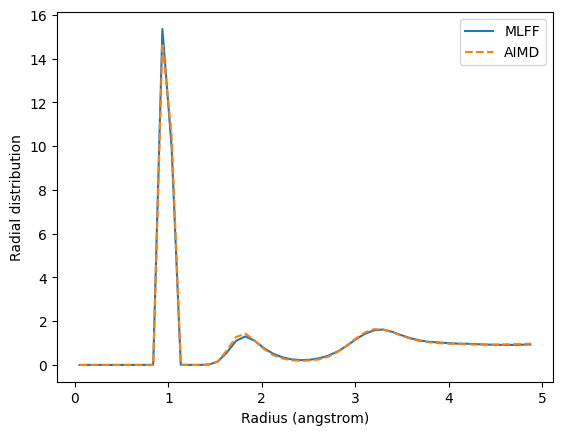

In [ ]:
plt.plot(OHrdf.bins, OHrdf.rdf, label='MLFF')
plt.plot(OHrdf_ref.bins, OHrdf_ref.rdf,label='AIMD', linestyle='--')
plt.legend()

plt.xlabel("Radius (angstrom)")
plt.ylabel("Radial distribution")

Text(0, 0.5, 'Radial distribution')

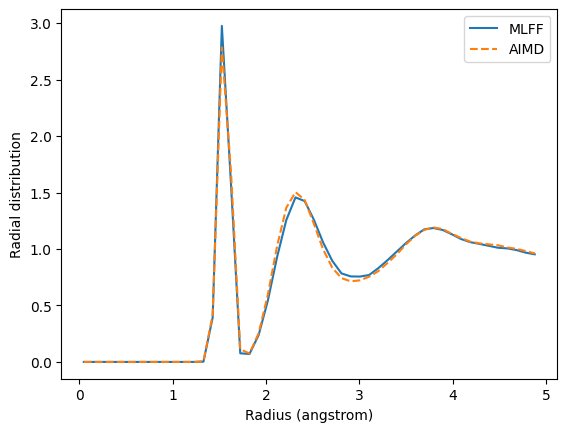

In [ ]:
plt.plot(HHrdf.bins, HHrdf.rdf, label='MLFF')
plt.plot(HHrdf_ref.bins, HHrdf_ref.rdf, label='AIMD',linestyle='--')
plt.legend()
plt.xlabel("Radius (angstrom)")
plt.ylabel("Radial distribution")

In [ ]:
import pandas as pd

Plot Total Energy and Temperature as a function of time after 5ps of equilibration to check the overall stability of the MD

<ipython-input-56-cdf14ff49038>:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  ener_file = pd.read_csv("/content/cp2k_run/water-1.ener", delim_whitespace=True, header = 0)


<Axes: xlabel='Time[fs]'>

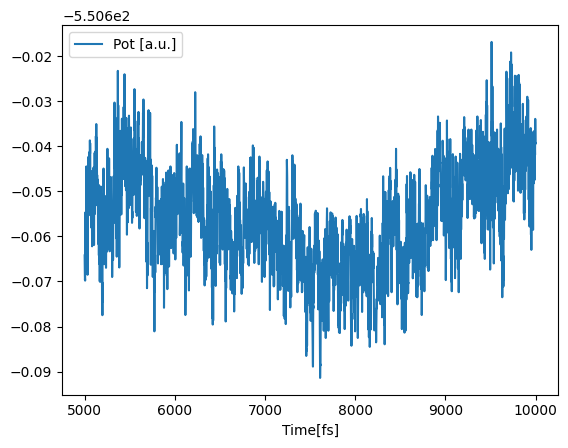

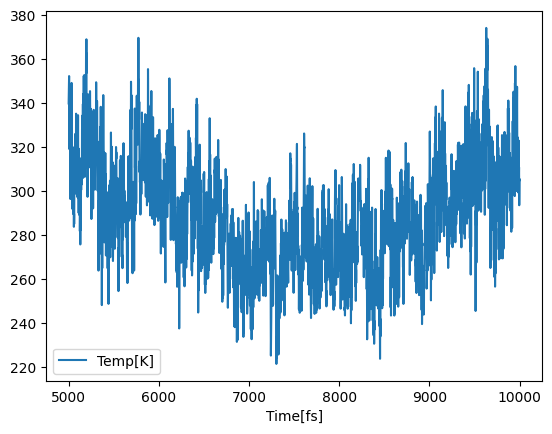

In [ ]:
import pandas as pd
ener_file = pd.read_csv("/content/cp2k_run/water-1.ener", delim_whitespace=True, header = 0)

ener_file = ener_file.drop(columns="#").rename(columns = {"Step" : "Time[fs]", "Nr.": "Kin.[a.u.]",
                                              "Time[fs]": "Temp[K]",
                                              "Kin.[a.u.]": "Pot [a.u.]","Temp[K]": "Cons Qty[a.u.]",
                                              "Pot.[a.u.]": "Used Time[s]"
                                              }).drop(columns=["Cons","Qty[a.u.]","UsedTime[s]"])
ener_file[10000:].plot(x="Time[fs]",y="Pot [a.u.]")
ener_file[10000:].plot(x="Time[fs]",y="Temp[K]")

### Try to do the same for an allegro model, below is an example input file

In [ ]:
allegro_input = """
# general
root: results/water-tutorial
run_name: water
seed: 42
dataset_seed: 42
append: true
default_dtype: float32

# -- network --
model_builders:
 - allegro.model.Allegro
 # the typical model builders from `nequip` can still be used:
 - PerSpeciesRescale
 - ForceOutput
 - RescaleEnergyEtc

# cutoffs
r_max: 4.5
avg_num_neighbors: auto

# radial basis
BesselBasis_trainable: true
PolynomialCutoff_p: 48

# symmetry
l_max: 2
parity: o3_full

# Allegro layers:
num_layers: 2
env_embed_multiplicity: 8
embed_initial_edge: true

two_body_latent_mlp_latent_dimensions: [32, 64, 128]
two_body_latent_mlp_nonlinearity: silu
two_body_latent_mlp_initialization: uniform

latent_mlp_latent_dimensions: [128]
latent_mlp_nonlinearity: silu
latent_mlp_initialization: uniform
latent_resnet: true

env_embed_mlp_latent_dimensions: []
env_embed_mlp_nonlinearity: null
env_embed_mlp_initialization: uniform

# - end allegro layers -

# Final MLP to go from Allegro latent space to edge energies:
edge_eng_mlp_latent_dimensions: [32]
edge_eng_mlp_nonlinearity: null
edge_eng_mlp_initialization: uniform

include_keys:
  - user_label
key_mapping:
  user_label: label0

# -- data --
dataset: ase
dataset_file_name: /content/cp2k/colab/AIMD_data/conc_wat_pos_frc.extxyz                     # path to data set file
ase_args:
  format: extxyz

# A mapping of chemical species to type indexes is necessary if the dataset is provided with atomic numbers instead of type indexes.
chemical_symbols:
  - H
  - O

# logging
wandb: false
#wandb_project: allegro-water-tutorial
verbose: info
log_batch_freq: 10

# training
n_train: 1000
n_val: 100
batch_size: 5
max_epochs: 100
learning_rate: 0.002
train_val_split: random
shuffle: true
metrics_key: validation_loss

# use an exponential moving average of the weights
use_ema: true
ema_decay: 0.99
ema_use_num_updates: true

# loss function
loss_coeffs:
  forces: 1.
  total_energy:
    - 1.
    - PerAtomMSELoss

# optimizer
optimizer_name: Adam
optimizer_params:
  amsgrad: false
  betas: !!python/tuple
  - 0.9
  - 0.999
  eps: 1.0e-08
  weight_decay: 0.

metrics_components:
  - - forces                               # key
    - mae                                  # "rmse" or "mae"
  - - forces
    - rmse
  - - total_energy
    - mae
  - - total_energy
    - mae
    - PerAtom: True                        # if true, energy is normalized by the number of atoms

# lr scheduler, drop lr if no improvement for 50 epochs
lr_scheduler_name: ReduceLROnPlateau
lr_scheduler_patience: 50
lr_scheduler_factor: 0.5

early_stopping_lower_bounds:
  LR: 1.0e-5

early_stopping_patiences:
  validation_loss: 100

global_rescale_shift: null
global_rescale_shift_trainable: false
global_rescale_scale: dataset_forces_rms
global_rescale_scale_trainable: false
per_species_rescale_shifts_trainable: false
per_species_rescale_scales_trainable: true
per_species_rescale_shifts: dataset_per_species_total_energy_mean
per_species_rescale_scales: dataset_per_species_forces_rms
"""

with open("allegro/configs/allegro-water-tutorial.yaml", "w") as f:
    f.write(allegro_input)